In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange, tqdm

In [ ]:
# Create a data distribution
def create_data(data_points):
    data_class1 = torch.rand(data_points, 2) * 1.45
    data_class2 = torch.rand(data_points, 2) * 3

    mask = ~((data_class2[:, 0] < 1.55) * (data_class2[:, 1] < 1.55))
    data_class2 = data_class2[mask]

    # Lables
    data_label1 = torch.zeros(data_class1.shape[0], 1)
    data_label2 = torch.ones(data_class2.shape[0], 1)

    # Combine data
    x_data = torch.cat((data_class1, data_class2), 0)
    y_data = torch.cat((data_label1, data_label2), 0)

    return x_data, y_data

In [ ]:
# Combine data
x_train, y_train = create_data(1000)
x_test, y_test = create_data(500)

In [ ]:
x_train[:5]

tensor([[0.5465, 1.1669],
        [0.2171, 0.9055],
        [0.4798, 0.6662],
        [0.5863, 0.9756],
        [0.7661, 0.5421]])

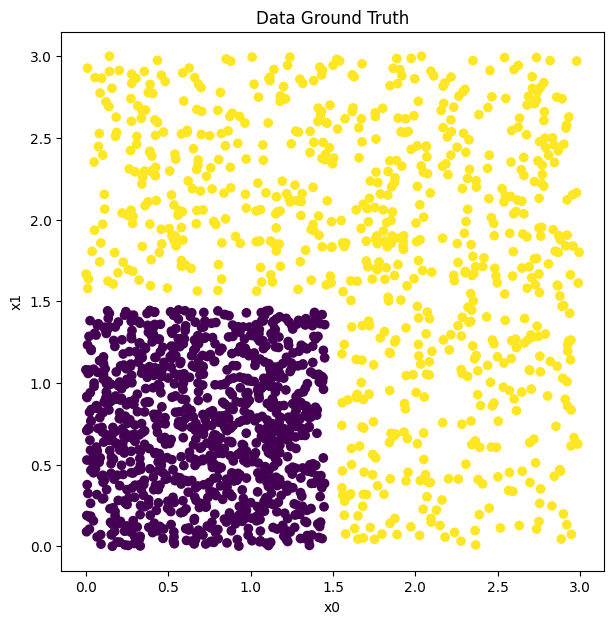

In [ ]:
# Lets see what the data looks like
plt.figure(figsize=(7, 7))
plt.scatter(x_train[:, 0].numpy(), x_train[:, 1].numpy(), c=y_train.flatten().numpy())
_ = plt.xlabel("x0")
_ = plt.ylabel("x1")
_ = plt.title("Data Ground Truth")

In [ ]:
logistic_linear = nn.Linear(2, 1)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(logistic_linear.parameters(), lr=0.01)

loss_log = []
acc_log = []
max_epoch = 100

for epoch in range(max_epoch):
  with torch.no_grad():
    y_hat = logistic_linear(x_test)
    y_pred = (y_hat>0).float()
    acc_log.append((y_pred == y_test).float().mean())

  y_pred = logistic_linear(x_train)
  loss = loss_fn(y_pred, y_train)
  loss_log.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

print('Accuracy of Model:', acc_log[-1].item())

Accuracy of Model: 0.7802071571350098


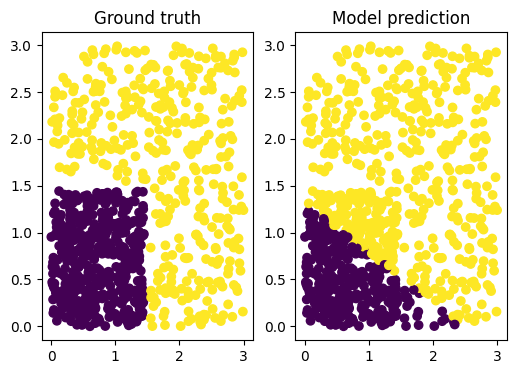

In [ ]:
with torch.no_grad():
  y_pred_test = logistic_linear(x_test)
  y_pred_test = (y_pred_test>0).float()

plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
plt.scatter(x_test[:,0].numpy(), x_test[:,1].numpy(),c=y_test.flatten().numpy())
plt.title('Ground truth');

plt.subplot(1,2,2)
plt.scatter(x_test[:,0].numpy(), x_test[:,1].numpy(),c=y_pred_test.flatten().numpy())
plt.title('Model prediction');

In [ ]:
# Using the equation 0 = w0*x0 + w1*x1 + w2
# Consider each input dimention intependantly
# Therefore we have 2 equations 0 = w0*x0 + w1
# -w1/w0 = 1.5
# Pick any w1 and calculate w0

# Mục đích của việc hàm F.linear là tính lại giá trị dựa theo 2 phương trình
# h0 ​= 1.x0 ​− 1.5
# h1 ​= 1.x1 ​− 1.5​
# Từ đây các giá trị x0 x1 ban đầu trong không gian 2D sẽ được điều chỉnh để đi qua activation function
w0 = 6
w1 = -(1.5 * w0)
w_0 = torch.FloatTensor([[w0, 0], [0, w0]])
b_0 = torch.FloatTensor([[w1, w1]])
print("Weights", w_0.numpy())
print("bias", b_0.numpy())

h1 = F.linear(x_train, w_0, bias=b_0)
h2 = torch.sigmoid(h1)

Weights [[6. 0.]
 [0. 6.]]
bias [[-9. -9.]]


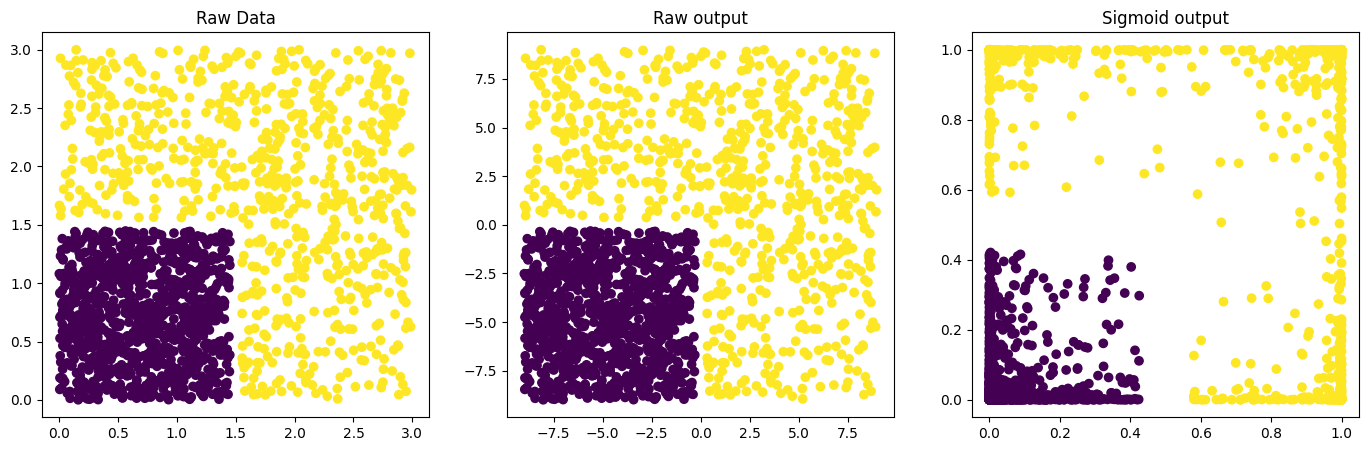

In [ ]:
# Plot out the Raw data vs Raw output and Sigmoid output
# What happens as you increase w0???
# Increase w0 untill the data becomes linearly seperable!

plt.figure(figsize=(17, 5))
plt.subplot(131)
plt.scatter(x_train[:, 0].numpy(), x_train[:, 1].numpy(), c=y_train.flatten().numpy())
plt.title("Raw Data")

plt.subplot(132)
plt.scatter(h1[:, 0].numpy(), h1[:, 1].numpy(), c=y_train.flatten().numpy())
plt.title("Raw output")

plt.subplot(133)
plt.scatter(h2[:, 0].numpy(), h2[:, 1].numpy(), c=y_train.flatten().numpy())
plt.title("Sigmoid output");

# Non Linear Logistic Regression

In [ ]:
class NonLinear(nn.Module):
  def __init__(self, input_size, output_size, hidden_size):
    super().__init__()
    self.linear1 = nn.Linear(input_size, hidden_size)
    self.linear2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    self.h1 = self.linear1(x)
    self.h2 = torch.sigmoid(self.h1)
    self.h3 = self.linear2(self.h2)
    return self.h3

In [ ]:
logistic_linear = NonLinear(input_size=2,output_size=1,hidden_size=2)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(logistic_linear.parameters(), lr =1e-2)

In [ ]:
from tqdm import trange

acc_logs = []
loss_logs = []
max_epoch = 5000

for epoch in trange(max_epoch, desc="Training Epochs"):
  with torch.no_grad():
    y_pred = logistic_linear(x_test)
    y_pred_cls = (y_pred > 0).float()
    acc = (y_pred_cls == y_test).float().mean()
    acc_logs.append(acc.item())

  y_hat = logistic_linear(x_train)
  loss = loss_fn(y_hat, y_train)
  loss_logs.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 500 == 0:
    print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | Acc: {acc.item()*100:.2f}%")

print('Độ chính xác cuối:', acc_logs[-1] * 100, "%")

Training Epochs:   2%|▏         | 116/5000 [00:00<00:08, 580.59it/s]

Epoch    0 | Loss: 0.0013 | Acc: 100.00%


Training Epochs:  12%|█▏        | 588/5000 [00:01<00:09, 488.47it/s]

Epoch  500 | Loss: 0.0010 | Acc: 100.00%


Training Epochs:  21%|██        | 1056/5000 [00:02<00:08, 483.54it/s]

...

Epoch 4000 | Loss: 0.0002 | Acc: 100.00%


Training Epochs:  92%|█████████▏| 4601/5000 [00:06<00:00, 822.14it/s]

Epoch 4500 | Loss: 0.0001 | Acc: 100.00%


Training Epochs: 100%|██████████| 5000/5000 [00:06<00:00, 727.94it/s]

Độ chính xác cuối: 100.0 %


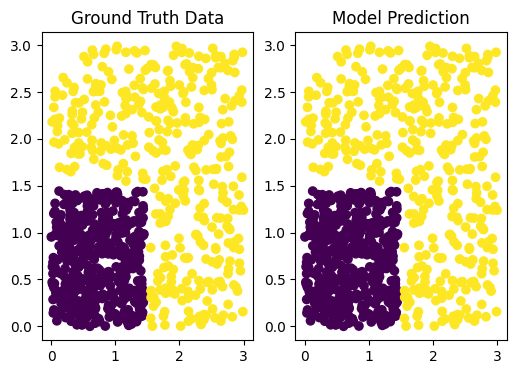

In [ ]:
with torch.no_grad():
  y_pred_test = logistic_linear(x_test)
  y_pred_test = (y_pred_test>0).float()
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
plt.scatter(x_test[:,0].numpy(), x_test[:,1].numpy(),c=y_test.flatten().numpy())
plt.title('Ground Truth Data')

plt.subplot(1,2,2)
plt.scatter(x_test[:,0].numpy(), x_test[:,1].numpy(),c=y_pred_test.flatten().numpy())
plt.title('Model Prediction');

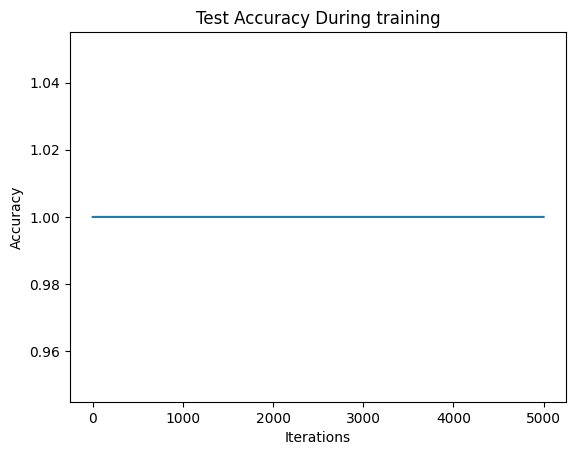

In [ ]:
plt.plot(acc_logs)
_ = plt.xlabel("Iterations")
_ = plt.ylabel("Accuracy")
_ = plt.title("Test Accuracy During training")


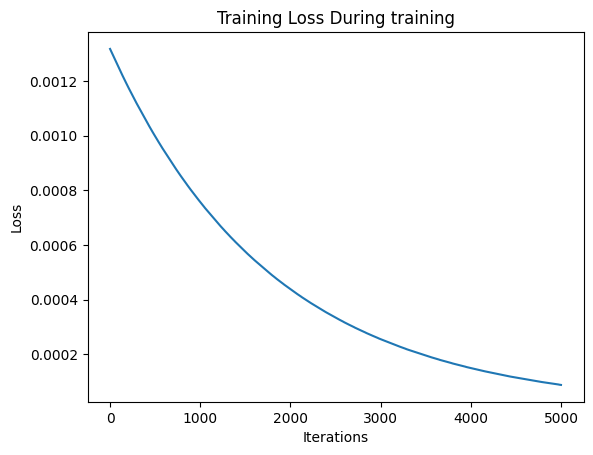

In [ ]:
plt.plot(loss_logs)
_ = plt.xlabel("Iterations")
_ = plt.ylabel("Loss")
_ = plt.title("Training Loss During training")

In [12]:
!git clone https://github.com/KhanhDao1512/Pytorch_implementation.git

Cloning into 'Pytorch_implementation'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [11]:
%cd Pytorch_implementation

[Errno 2] No such file or directory: 'Pytorch_implementation'
/content/Pytorch_implementation


In [19]:
!git config --global user.email "dtk1512@gmail.com"
!git config --global user.name "KhanhDao1512"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!cp -r '/content/drive/MyDrive/Colab - Khanh/Pytorch/'* .

In [16]:
!git add .
!git commit -m "Upload ML folder"


On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   Data (modified content)

no changes added to commit (use "git add" and/or "git commit -a")
fatal: could not read Username for 'https://github.com': No such device or address


In [18]:
!git push

fatal: could not read Username for 'https://github.com': No such device or address
